# Caso 7 — Medical Cost Prediction (Seguros)

**Rol simulado:** Actuario/a de datos junior  
**Dataset:** [Medical Cost Personal Datasets — Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)

Este cuaderno desarrolla solamente lo solicitado para el caso:

1. **Regresión:** predecir `charges` (gastos médicos anuales).
2. **Clasificación/imputación:** recuperar `smoker` cuando falta mediante una simulación reproducible.

La metodología sigue los laboratorios de clase: exploración, partición antes del ajuste, `ColumnTransformer` + `Pipeline`, baseline, mejora, métricas, diagnóstico visual e interpretación.


## 1. Preparación del entorno y reproducibilidad

**Guía:** ejecuta las celdas en orden. La semilla fija permite repetir exactamente las divisiones y la simulación de datos faltantes. No se requieren librerías fuera de `numpy`, `pandas`, `matplotlib` y `scikit-learn`.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
    classification_report, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, precision_score,
    r2_score, recall_score, roc_auc_score
)
from sklearn.model_selection import (
    GridSearchCV, KFold, StratifiedKFold, learning_curve, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")

print("Entorno preparado. Semilla:", RANDOM_STATE)


Entorno preparado. Semilla: 42


## 2. Carga y validación del dataset

**Guía:** se usa una ruta relativa para que el repositorio funcione en otra computadora. El código también contempla ejecutar el notebook desde la carpeta raíz o desde `notebooks/`.


In [2]:
candidatos = [Path("data/insurance.csv"), Path("../data/insurance.csv")]
DATA_PATH = next((ruta for ruta in candidatos if ruta.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró insurance.csv. Colócalo en data/insurance.csv desde la raíz del proyecto."
    )

df = pd.read_csv(DATA_PATH)
columnas_esperadas = {"age", "sex", "bmi", "children", "smoker", "region", "charges"}
assert columnas_esperadas == set(df.columns), "Las columnas no coinciden con el dataset esperado."
assert len(df) > 0 and not df.duplicated().all(), "El dataset está vacío o no es válido."

print(f"Archivo: {DATA_PATH.resolve()}")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())


Archivo: /home/claude/medical-cost-repo/data/insurance.csv
Dimensiones: 1338 filas x 7 columnas


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Exploración y calidad del dato (EDA)

**Guía:** antes de modelar comprobamos tipos, nulos, duplicados, categorías, distribuciones y posibles valores extremos. Un valor extremo no se elimina automáticamente: puede representar un gasto médico real y relevante para el negocio.


In [3]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "unicos": df.nunique(),
})
display(resumen)
print("Filas duplicadas:", df.duplicated().sum())
print("\nCategorías:")
for columna in ["sex", "smoker", "region"]:
    print(f"- {columna}: {sorted(df[columna].unique())}")
display(df.describe(include="all").T)


,tipo,nulos,unicos
age,int64,0,47
sex,str,0,2
bmi,float64,0,548
children,int64,0,6
smoker,str,0,2
region,str,0,4
charges,float64,0,1337


Filas duplicadas: 1

Categorías:
- sex: ['female', 'male']
- smoker: ['no', 'yes']
- region: ['northeast', 'northwest', 'southeast', 'southwest']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


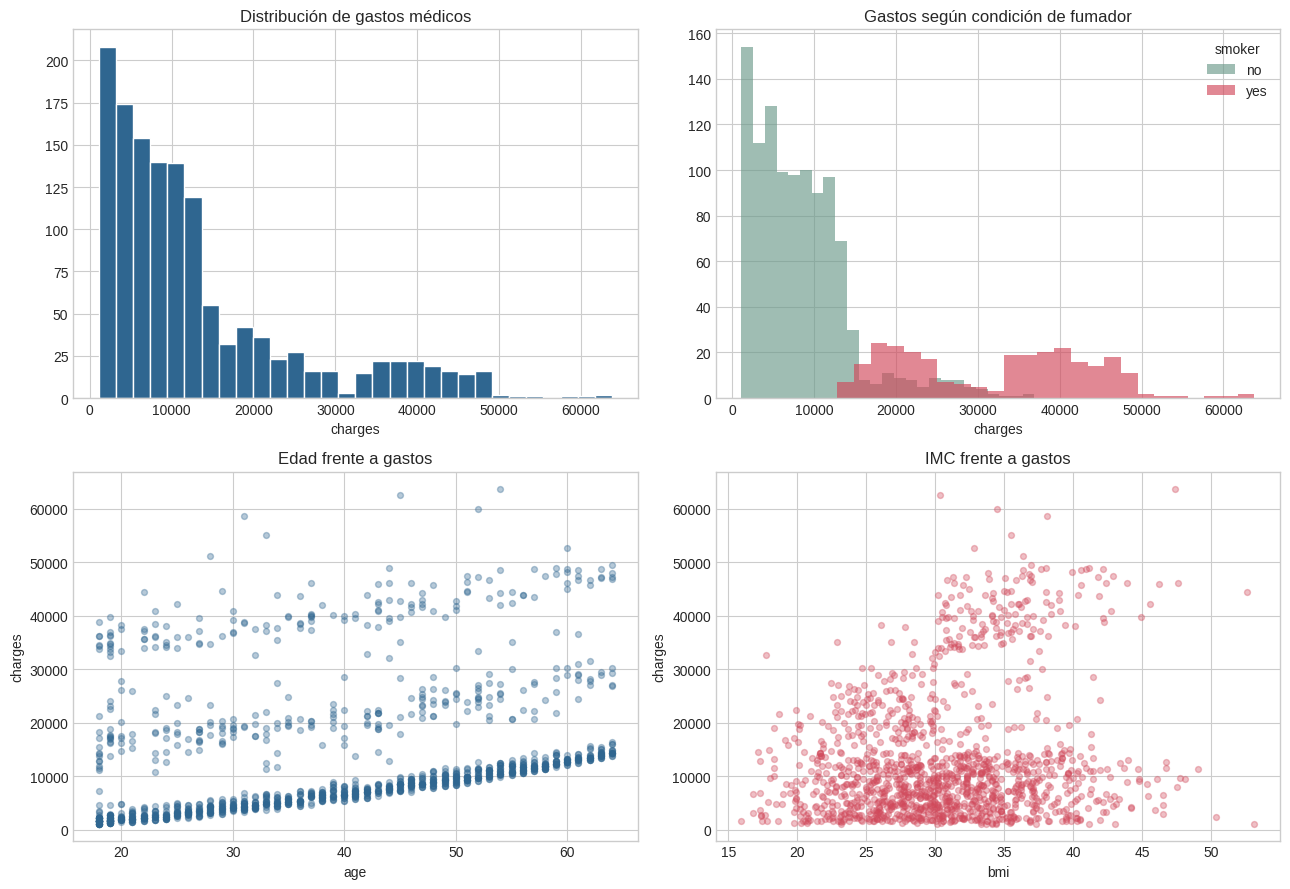

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(df["charges"], bins=30, color="#2F6690", edgecolor="white")
axes[0, 0].set_title("Distribución de gastos médicos")
axes[0, 0].set_xlabel("charges")

for valor, color in [("no", "#6C9A8B"), ("yes", "#D1495B")]:
    datos = df.loc[df["smoker"] == valor, "charges"]
    axes[0, 1].hist(datos, bins=25, alpha=0.65, label=valor, color=color)
axes[0, 1].set_title("Gastos según condición de fumador")
axes[0, 1].set_xlabel("charges")
axes[0, 1].legend(title="smoker")

axes[1, 0].scatter(df["age"], df["charges"], alpha=0.35, s=18, color="#2F6690")
axes[1, 0].set_title("Edad frente a gastos")
axes[1, 0].set_xlabel("age")
axes[1, 0].set_ylabel("charges")

axes[1, 1].scatter(df["bmi"], df["charges"], alpha=0.35, s=18, color="#D1495B")
axes[1, 1].set_title("IMC frente a gastos")
axes[1, 1].set_xlabel("bmi")
axes[1, 1].set_ylabel("charges")

plt.tight_layout()
plt.show()


In [5]:
q1, q3 = df["charges"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
posibles_extremos = (df["charges"] > limite_superior).sum()

print(f"Asimetría de charges: {df['charges'].skew():.3f}")
print(f"Posibles extremos por regla IQR: {posibles_extremos}")
print("Decisión: se conservan; son observaciones plausibles y relevantes para estimar riesgo.")


Asimetría de charges: 1.516
Posibles extremos por regla IQR: 139
Decisión: se conservan; son observaciones plausibles y relevantes para estimar riesgo.


## 4. Ingeniería de características obligatoria

La guía pide documentar los mapeos y crear la interacción:

- `sex`: `female → 0`, `male → 1`.
- `smoker`: `no → 0`, `yes → 1`.
- `BMI_Smoker = bmi × smoker`.

**Interpretación:** esta interacción permite que el efecto del IMC sea distinto para fumadores y no fumadores. Se crea dentro del pipeline para conservar la reproducibilidad.


In [6]:
class CrearVariablesMedicas(BaseEstimator, TransformerMixin):
    # Mapea variables binarias y crea BMI_Smoker sin modificar el DataFrame original.

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["sex"] = X["sex"].map({"female": 0, "male": 1})
        X["smoker"] = X["smoker"].map({"no": 0, "yes": 1})
        X["BMI_Smoker"] = X["bmi"] * X["smoker"]
        return X

    def get_feature_names_out(self, input_features=None):
        base = list(input_features) if input_features is not None else []
        return np.asarray(base + ["BMI_Smoker"], dtype=object)


## 5. Regresión: predecir `charges`

### 5.1 División de datos

**Guía:** el conjunto de prueba se separa antes de ajustar transformaciones o modelos. Se reserva el 20% para una evaluación final comparable. Ninguna estadística del test entra al entrenamiento.


In [7]:
X_reg = df.drop(columns="charges")
y_reg = df["charges"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

columnas_numericas_reg = ["age", "bmi", "children", "BMI_Smoker"]
columnas_binarias_reg = ["sex", "smoker"]
columnas_categoricas_reg = ["region"]

preprocesador_reg = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), columnas_numericas_reg),
        ("bin", SimpleImputer(strategy="most_frequent"), columnas_binarias_reg),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), columnas_categoricas_reg),
    ],
    verbose_feature_names_out=False,
)

print("Entrenamiento:", X_train_reg.shape, "| Prueba:", X_test_reg.shape)


Entrenamiento: (1070, 6) | Prueba: (268, 6)


### 5.2 Baseline: regresión lineal

El baseline establece un punto de comparación sencillo e interpretable. Todo el preprocesamiento permanece dentro del pipeline.


In [8]:
modelo_lineal = Pipeline([
    ("features", CrearVariablesMedicas()),
    ("preprocesamiento", preprocesador_reg),
    ("modelo", LinearRegression()),
])

modelo_lineal.fit(X_train_reg, y_train_reg)
pred_lineal = modelo_lineal.predict(X_test_reg)


### 5.3 Mejora: `PolynomialFeatures(degree=2)` + Ridge

Esta alternativa captura relaciones no lineales e interacciones adicionales. Ridge limita coeficientes excesivos y ayuda a controlar la colinealidad creada por los términos polinomiales. `alpha` se elige solo con validación cruzada sobre entrenamiento.


In [9]:
pipeline_ridge = Pipeline([
    ("features", CrearVariablesMedicas()),
    ("preprocesamiento", preprocesador_reg),
    ("polinomios", PolynomialFeatures(degree=2, include_bias=False)),
    ("modelo", Ridge()),
])

cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
busqueda_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid={"modelo__alpha": [0.1, 1.0, 10.0, 100.0]},
    scoring="neg_mean_absolute_error",
    cv=cv_reg,
    n_jobs=1,
)
busqueda_ridge.fit(X_train_reg, y_train_reg)
modelo_ridge = busqueda_ridge.best_estimator_
pred_ridge = modelo_ridge.predict(X_test_reg)

print("Mejor alpha:", busqueda_ridge.best_params_["modelo__alpha"])
print("MAE promedio de CV:", round(-busqueda_ridge.best_score_, 2))


Mejor alpha: 1.0
MAE promedio de CV: 2968.4


### 5.4 Evaluación comparativa

- **MAE:** error absoluto medio expresado en las mismas unidades monetarias de `charges`.
- **RMSE:** penaliza con mayor fuerza los errores grandes.
- **R²:** proporción de variabilidad explicada por el modelo.

La decisión debe considerar las tres métricas, no solo una.


In [10]:
def metricas_regresion(nombre, y_real, y_pred):
    return {
        "modelo": nombre,
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": mean_squared_error(y_real, y_pred) ** 0.5,
        "R2": r2_score(y_real, y_pred),
    }

tabla_regresion = pd.DataFrame([
    metricas_regresion("Regresión lineal", y_test_reg, pred_lineal),
    metricas_regresion("Polinomios grado 2 + Ridge", y_test_reg, pred_ridge),
]).set_index("modelo")

display(tabla_regresion.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))


,MAE,RMSE,R2
modelo,,,
Regresión lineal,"2,756.90","4,573.81",0.8653
Polinomios grado 2 + Ridge,"2,689.80","4,591.33",0.8642


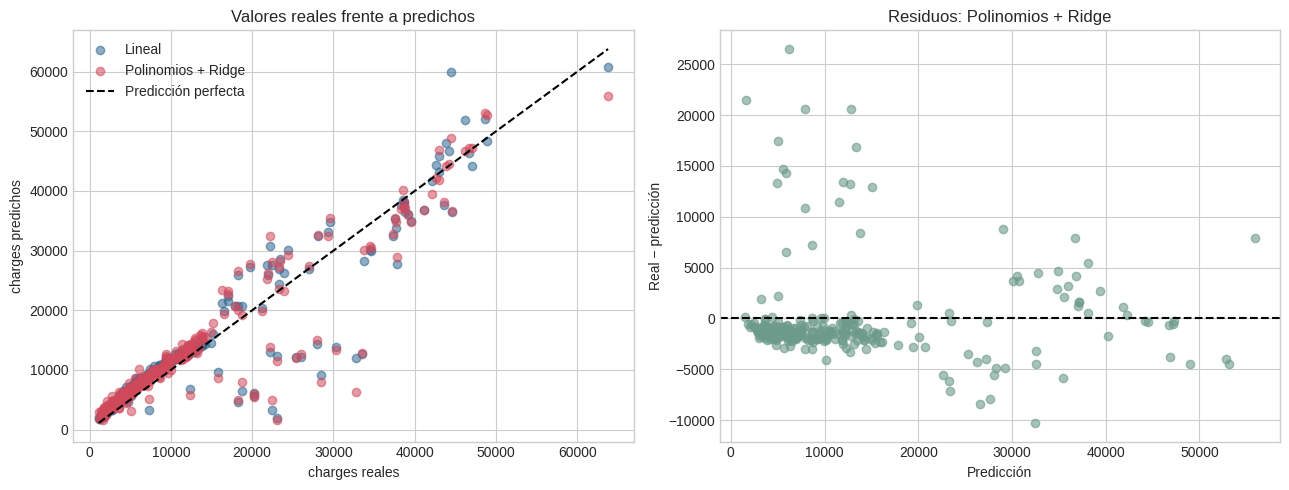

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_reg, pred_lineal, alpha=0.55, label="Lineal", color="#2F6690")
axes[0].scatter(y_test_reg, pred_ridge, alpha=0.55, label="Polinomios + Ridge", color="#D1495B")
limites = [min(y_test_reg.min(), pred_lineal.min(), pred_ridge.min()),
           max(y_test_reg.max(), pred_lineal.max(), pred_ridge.max())]
axes[0].plot(limites, limites, "k--", label="Predicción perfecta")
axes[0].set_title("Valores reales frente a predichos")
axes[0].set_xlabel("charges reales")
axes[0].set_ylabel("charges predichos")
axes[0].legend()

residuos = y_test_reg - pred_ridge
axes[1].scatter(pred_ridge, residuos, alpha=0.6, color="#6C9A8B")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Residuos: Polinomios + Ridge")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real − predicción")

plt.tight_layout()
plt.show()


### 5.5 Curvas de aprendizaje

**Guía:** sirven para diagnosticar si más datos podrían ayudar y si existe una brecha persistente entre entrenamiento y validación. Se usa MAE negativo porque scikit-learn maximiza los scores; para graficar se cambia el signo.


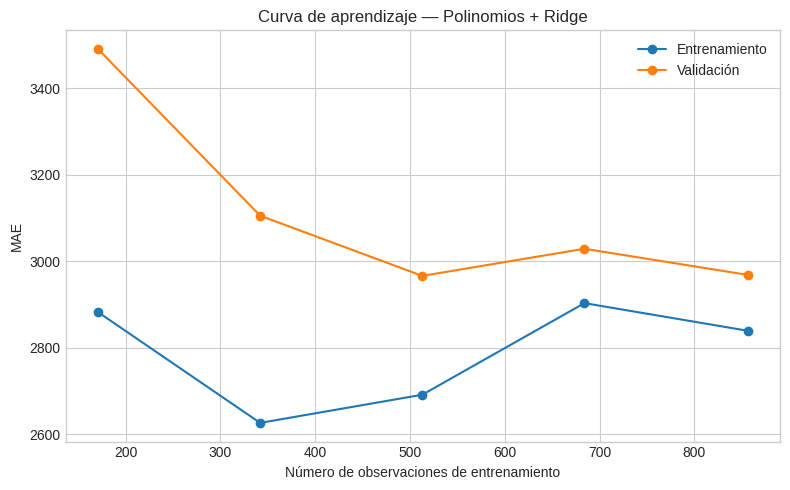

In [12]:
tamanos, score_train, score_valid = learning_curve(
    modelo_ridge,
    X_train_reg,
    y_train_reg,
    cv=cv_reg,
    scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=1,
)

mae_train = -score_train.mean(axis=1)
mae_valid = -score_valid.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(tamanos, mae_train, "o-", label="Entrenamiento")
plt.plot(tamanos, mae_valid, "o-", label="Validación")
plt.title("Curva de aprendizaje — Polinomios + Ridge")
plt.xlabel("Número de observaciones de entrenamiento")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()


### 5.6 Interpretación de coeficientes

Los coeficientes se muestran como **señales del modelo**, no como efectos causales. En el modelo polinomial cada término puede combinar variables; por eso interesa revisar magnitud y signo junto con conocimiento actuarial.


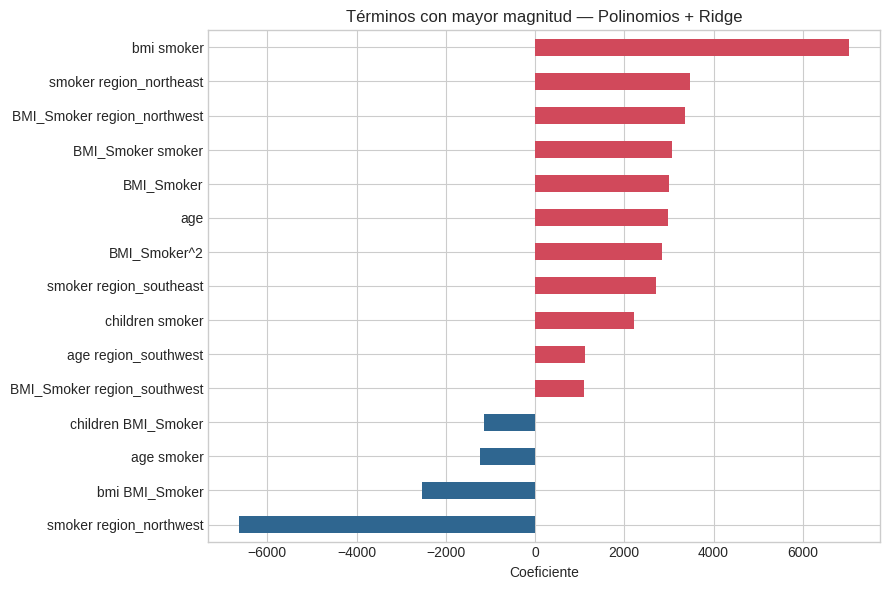

,coeficiente
smoker region_northwest,-6636.900656
bmi BMI_Smoker,-2523.642640
age smoker,-1226.770376
children BMI_Smoker,-1154.554459
BMI_Smoker region_southwest,1098.706531
age region_southwest,1115.186656
children smoker,2220.294179
smoker region_southeast,2710.389300
BMI_Smoker^2,2841.301274
age,2977.541448


In [13]:
nombres_base = modelo_ridge.named_steps["preprocesamiento"].get_feature_names_out()
nombres_poly = modelo_ridge.named_steps["polinomios"].get_feature_names_out(nombres_base)
coeficientes = pd.Series(
    modelo_ridge.named_steps["modelo"].coef_, index=nombres_poly, name="coeficiente"
)
top_coef = coeficientes.loc[coeficientes.abs().sort_values(ascending=False).head(15).index].sort_values()

plt.figure(figsize=(9, 6))
colores = np.where(top_coef >= 0, "#D1495B", "#2F6690")
top_coef.plot(kind="barh", color=colores)
plt.title("Términos con mayor magnitud — Polinomios + Ridge")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()
display(top_coef.to_frame())


## 6. Clasificación para imputar `smoker`

### 6.1 Simulación reproducible de registros incompletos

Se oculta el 20% de las etiquetas `smoker` con semilla fija. Esas filas actúan como casos faltantes y también permiten evaluar la recuperación porque conservamos la verdad únicamente para validación.

**Decisión contra fuga:** `charges` no se usa como predictor. Si queremos imputar `smoker` antes de estimar gastos, el gasto objetivo todavía no estaría disponible en una aplicación real.


In [14]:
rng = np.random.default_rng(RANDOM_STATE)
indices_ocultos = rng.choice(df.index, size=int(0.20 * len(df)), replace=False)

df_simulado = df.copy()
smoker_real_oculto = df_simulado.loc[indices_ocultos, "smoker"].map({"no": 0, "yes": 1})
df_simulado.loc[indices_ocultos, "smoker"] = np.nan

predictores_clf = ["age", "sex", "bmi", "children", "region"]
indices_conocidos = df_simulado.index[df_simulado["smoker"].notna()]
X_clf = df_simulado.loc[indices_conocidos, predictores_clf]
y_clf = df_simulado.loc[indices_conocidos, "smoker"].map({"no": 0, "yes": 1})
X_faltantes = df_simulado.loc[indices_ocultos, predictores_clf]

X_train_clf, X_valid_clf, y_train_clf, y_valid_clf = train_test_split(
    X_clf, y_clf, test_size=0.25, stratify=y_clf, random_state=RANDOM_STATE
)

print("Smoker ocultos simulados:", len(indices_ocultos))
print("Distribución conocida (0=no, 1=yes):")
display(y_clf.value_counts(normalize=True).sort_index().rename("proporción").to_frame())


Smoker ocultos simulados: 267
Distribución conocida (0=no, 1=yes):


,proporción
smoker,
0,0.798319
1,0.201681


### 6.2 Pipeline de regresión logística

La regresión logística es el baseline solicitado. Las variables numéricas se imputan y escalan; `sex` y `region` se imputan y codifican dentro del pipeline.


In [15]:
numericas_clf = ["age", "bmi", "children"]
categoricas_clf = ["sex", "region"]

preprocesador_clf = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numericas_clf),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categoricas_clf),
])

modelo_smoker = Pipeline([
    ("preprocesamiento", preprocesador_clf),
    ("modelo", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

modelo_smoker.fit(X_train_clf, y_train_clf)
prob_valid = modelo_smoker.predict_proba(X_valid_clf)[:, 1]
pred_valid = (prob_valid >= 0.50).astype(int)

print(f"ROC-AUC validación: {roc_auc_score(y_valid_clf, prob_valid):.4f}")
print(classification_report(y_valid_clf, pred_valid, target_names=["no", "yes"], zero_division=0))


ROC-AUC validación: 0.5267
              precision    recall  f1-score   support

          no       0.82      0.59      0.68       214
         yes       0.23      0.48      0.31        54

    accuracy                           0.57       268
   macro avg       0.52      0.54      0.50       268
weighted avg       0.70      0.57      0.61       268



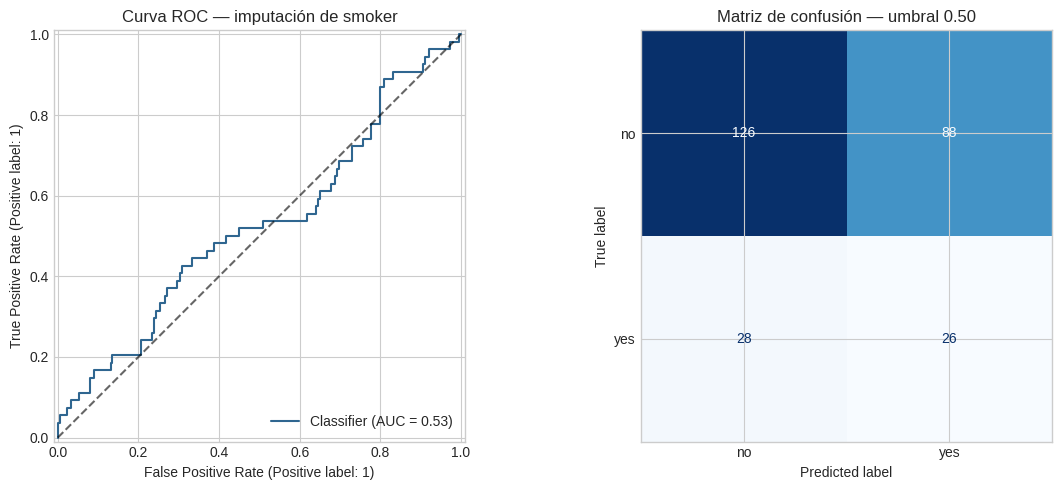

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_valid_clf, prob_valid, ax=axes[0], color="#2F6690")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.6)
axes[0].set_title("Curva ROC — imputación de smoker")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_valid_clf, pred_valid),
    display_labels=["no", "yes"],
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Matriz de confusión — umbral 0.50")

plt.tight_layout()
plt.show()


### 6.3 Análisis de umbrales y costos FP/FN

- **Falso positivo (FP):** imputar “fumador” a una persona no fumadora; puede sobreestimar riesgo o prima.
- **Falso negativo (FN):** imputar “no fumador” a una persona fumadora; puede subestimar riesgo y costo esperado.

La exactitud no basta. La tabla permite comparar `precision`, `recall`, F1, FP y FN. No se asignan costos monetarios inventados: el umbral definitivo debe fijarse con valores proporcionados por la aseguradora.


In [17]:
filas_umbral = []
for umbral in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred_u = (prob_valid >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid_clf, pred_u).ravel()
    filas_umbral.append({
        "umbral": umbral,
        "accuracy": accuracy_score(y_valid_clf, pred_u),
        "precision": precision_score(y_valid_clf, pred_u, zero_division=0),
        "recall": recall_score(y_valid_clf, pred_u, zero_division=0),
        "F1": f1_score(y_valid_clf, pred_u, zero_division=0),
        "FP": fp,
        "FN": fn,
    })

tabla_umbrales = pd.DataFrame(filas_umbral).set_index("umbral")
display(tabla_umbrales.style.format({
    "accuracy": "{:.3f}", "precision": "{:.3f}", "recall": "{:.3f}", "F1": "{:.3f}"
}))


,accuracy,precision,recall,F1,FP,FN
umbral,,,,,,
0.300000,0.201,0.201,1.000,0.335,214,0
0.400000,0.269,0.204,0.907,0.333,191,5
0.500000,0.567,0.228,0.481,0.310,88,28
0.600000,0.791,0.400,0.074,0.125,6,50
0.700000,0.799,0.000,0.000,0.000,0,54


### 6.4 Recuperación del subconjunto oculto

**Guía:** se reentrena el mismo pipeline con todas las etiquetas conocidas y se imputan las filas simuladas como faltantes. La columna original no se sobrescribe; se crea `smoker_imputado` para mantener trazabilidad.


In [18]:
modelo_smoker.fit(X_clf, y_clf)
prob_ocultos = modelo_smoker.predict_proba(X_faltantes)[:, 1]
umbral_operativo_demo = 0.50  # Cambiar solo cuando el negocio defina costos FP/FN.
pred_ocultos = (prob_ocultos >= umbral_operativo_demo).astype(int)

df_imputado = df_simulado.copy()
df_imputado["smoker_imputado"] = df_imputado["smoker"]
df_imputado.loc[indices_ocultos, "smoker_imputado"] = np.where(pred_ocultos == 1, "yes", "no")

auc_ocultos = roc_auc_score(smoker_real_oculto, prob_ocultos)
print(f"ROC-AUC sobre registros ocultos simulados: {auc_ocultos:.4f}")
print("Valores pendientes después de imputar:", df_imputado["smoker_imputado"].isna().sum())
display(df_imputado.loc[indices_ocultos, predictores_clf + ["smoker", "smoker_imputado"]].head(10))


ROC-AUC sobre registros ocultos simulados: 0.5646
Valores pendientes después de imputar: 0


,age,sex,bmi,children,region,smoker,smoker_imputado
335,64,male,34.500,0,southwest,NaN,no
529,18,male,25.460,0,northeast,NaN,yes
535,38,male,28.025,1,northeast,NaN,yes
892,54,male,24.035,0,northeast,NaN,yes
626,36,male,28.880,3,northeast,NaN,yes
54,40,female,28.690,3,northwest,NaN,no
131,61,female,22.040,0,northeast,NaN,no
546,28,male,35.435,0,northeast,NaN,yes
577,31,female,38.095,1,northeast,NaN,no
279,51,female,21.560,1,southeast,NaN,yes


## 7. Conclusiones y recomendaciones

**Esta celda se completa automáticamente con los resultados obtenidos al ejecutar el notebook.** Las conclusiones diferencian evidencia del dataset, decisiones metodológicas y decisiones pendientes del negocio.


In [19]:
mejor_nombre = tabla_regresion["MAE"].idxmin()
mejor_mae = tabla_regresion.loc[mejor_nombre, "MAE"]
mejor_r2 = tabla_regresion.loc[mejor_nombre, "R2"]
auc_valid = roc_auc_score(y_valid_clf, prob_valid)

print("CONCLUSIONES BASADAS EN ESTA EJECUCIÓN")
print(f"1. El menor MAE de prueba corresponde a '{mejor_nombre}': {mejor_mae:,.2f}, con R²={mejor_r2:.4f}.")
print("2. Los residuos y la diferencia RMSE–MAE deben revisarse porque charges presenta asimetría y gastos altos reales.")
print(f"3. La regresión logística alcanza ROC-AUC={auc_valid:.4f} en validación para recuperar smoker.")
print("4. BMI_Smoker se incluyó dentro del pipeline y representa el efecto combinado exigido por la guía.")
print("\nRECOMENDACIONES DE NEGOCIO")
print("- Usar la estimación como apoyo actuarial, no como decisión automática de cobertura o precio.")
print("- Definir con el área actuarial el costo monetario de FP y FN antes de fijar el umbral de imputación.")
print("- Marcar cada smoker imputado y su probabilidad para revisión; no presentarlo como dato observado.")
print("- Monitorear MAE/RMSE por grupos y periodo antes de desplegar el modelo.")
print("\nLIMITACIONES")
print("- Dataset pequeño y sin dimensión temporal; no prueba generalización a otra población o año.")
print("- Las asociaciones no implican causalidad.")
print("- La clasificación simula faltantes aleatorios; faltantes reales podrían seguir otro mecanismo.")


CONCLUSIONES BASADAS EN ESTA EJECUCIÓN
1. El menor MAE de prueba corresponde a 'Polinomios grado 2 + Ridge': 2,689.80, con R²=0.8642.
2. Los residuos y la diferencia RMSE–MAE deben revisarse porque charges presenta asimetría y gastos altos reales.
3. La regresión logística alcanza ROC-AUC=0.5267 en validación para recuperar smoker.
4. BMI_Smoker se incluyó dentro del pipeline y representa el efecto combinado exigido por la guía.

RECOMENDACIONES DE NEGOCIO
- Usar la estimación como apoyo actuarial, no como decisión automática de cobertura o precio.
- Definir con el área actuarial el costo monetario de FP y FN antes de fijar el umbral de imputación.
- Marcar cada smoker imputado y su probabilidad para revisión; no presentarlo como dato observado.
- Monitorear MAE/RMSE por grupos y periodo antes de desplegar el modelo.

LIMITACIONES
- Dataset pequeño y sin dimensión temporal; no prueba generalización a otra población o año.
- Las asociaciones no implican causalidad.
- La clasificación si

## 8. Checklist de reproducibilidad

- [x] Dataset cargado mediante ruta relativa.
- [x] Semilla fija.
- [x] Separación de entrenamiento/prueba antes del ajuste.
- [x] `ColumnTransformer` + `Pipeline` para evitar fuga.
- [x] Mapeos explícitos y `BMI_Smoker` dentro del pipeline.
- [x] Baseline lineal y mejora con polinomios + Ridge.
- [x] R², MAE y RMSE reportados.
- [x] Curva de aprendizaje y análisis de coeficientes.
- [x] Simulación reproducible de `smoker` faltante.
- [x] Regresión logística, ROC-AUC, curva ROC, matriz de confusión y umbrales.
- [x] Recomendaciones y limitaciones sin afirmar causalidad.

> Antes de entregar: ejecutar **Restart Kernel and Run All Cells** y confirmar que no existan errores.
